# LGBM + SHAP 해석 분석

OLS 예측에서 확정한 `final_aic_features`를 사용해 LGBM을 전체 데이터로 학습하고,
SHAP으로 변수의 비선형 효과를 분해한다. OLS 해석 결과(β)와 변수별로 매칭하여
**견고한 효과 / 비선형 효과 / 선형으로 충분 / 무의미** 케이스를 분류한다.

- 입력: `../data/Finance_Final/dataset4_derived_full_with_dummies.csv`
- 설정: `../outputs/baseline/final_features.json`
- OLS 해석: `../outputs/baseline/ols_interpretation_coefficients.csv`
- 출력: `../outputs/baseline/lgbm_shap_summary.csv`, `interpretation_compare.csv`, `shap_values.npy`, PNG 3종

## 1. 설정 로드 + 데이터 준비

In [ ]:
# import sys
# !{sys.executable} -m pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 13.5 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ----- ---------------------------------- 5.5/38.1 MB 28.1 MB/s eta 0:00:02
   ------------- -------------------------- 13.1/38.1 MB 32.3 MB/s eta 0:00:01
   --------------------- ------------------ 21.0/38.1 MB 34.6 MB/s eta 0:00:01
   ------------------------------ --------- 29.4/38.1 MB 36.1 MB/s eta 0:00:01
   ------------------------------------- -- 35.9/38.1 MB 34.8 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 33.6 MB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 32.3 MB/s  0:00:00

   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import shap
from sklearn.metrics import r2_score, mean_squared_error

DATA_PATH = Path('../data/Finance_Final/dataset4_derived_full_with_dummies.csv')
BASELINE_DIR = Path('../outputs/baseline')
CFG_PATH = BASELINE_DIR / 'final_features.json'
OLS_PATH = BASELINE_DIR / 'ols_interpretation_coefficients.csv'

with open(CFG_PATH) as f:
    cfg = json.load(f)

target = cfg['target']
final_aic_features = cfg['final_aic_features']
print(f'target: {target}')
print(f'n_features: {len(final_aic_features)}')
print('features:', final_aic_features)

target: oil_diff_target
n_features: 19
features: ['OilPrice', 'RealInterestRate', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'oil_diff_lag1', 'oil_volatility_20', 'MA_ratio', 'MA_5_gt_MA_20', 'is_friday', 'gfc_2008_shock', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'war_2022_shock', 'war_2022_window', 'cond_opec_cut']


c:\Users\이은서\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv(DATA_PATH)
needed = final_aic_features + [target]
df_model = df[needed].dropna().reset_index(drop=True)

X = df_model[final_aic_features].copy()
y = df_model[target].copy()
print('전체 표본 수:', len(df_model))
print('X shape:', X.shape, '/ y shape:', y.shape)

전체 표본 수: 4798
X shape: (4798, 19) / y shape: (4798,)


## 2. LGBM 학습 (전체 데이터, 튜닝 없음)

In [5]:
lgbm = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
)
lgbm.fit(X, y)

pred = lgbm.predict(X)
r2 = r2_score(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
print(f'in-sample R²  : {r2:.4f}')
print(f'in-sample RMSE: {rmse:.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001030 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2448
[LightGBM] [Info] Number of data points in the train set: 4798, number of used features: 19
[LightGBM] [Info] Start training from score 0.007511
in-sample R²  : 0.5380
in-sample RMSE: 1.3679


## 3. SHAP 값 계산

In [6]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X)
expected_value = explainer.expected_value

print('shap_values shape:', np.array(shap_values).shape)
print('expected_value:', expected_value)

shap_values shape: (4798, 19)
expected_value: 0.00751146237586318


## 4. SHAP 요약 표

In [8]:
shap_arr = np.array(shap_values)

shap_summary = pd.DataFrame({
    'variable': final_aic_features,
    'mean_abs_shap': np.abs(shap_arr).mean(axis=0),
    'mean_shap_signed': shap_arr.mean(axis=0),
    'sign_positive_ratio': (shap_arr > 0).mean(axis=0),
})
shap_summary = shap_summary.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_summary['rank'] = np.arange(1, len(shap_summary) + 1)
shap_summary

,variable,mean_abs_shap,mean_shap_signed,sign_positive_ratio,rank
0,MA_ratio,0.152826,2.129844e-02,0.358274,1
1,OilPrice,0.139621,-6.809448e-04,0.481242,2
2,oil_volatility_20,0.135443,-3.757939e-03,0.566486,3
3,oil_diff_lag1,0.101643,7.799771e-05,0.513964,4
4,OilInventories,0.101028,-4.680036e-03,0.482076,5
5,VIX,0.093688,2.004797e-03,0.453731,6
6,CPE,0.088988,-5.919745e-03,0.629846,7
7,IndustryProduction,0.071611,-3.074668e-03,0.517090,8
8,RealInterestRate,0.071107,-1.195190e-07,0.428303,9
9,OPECProduction,0.059750,-2.810070e-04,0.566069,10


## 5. SHAP 시각화

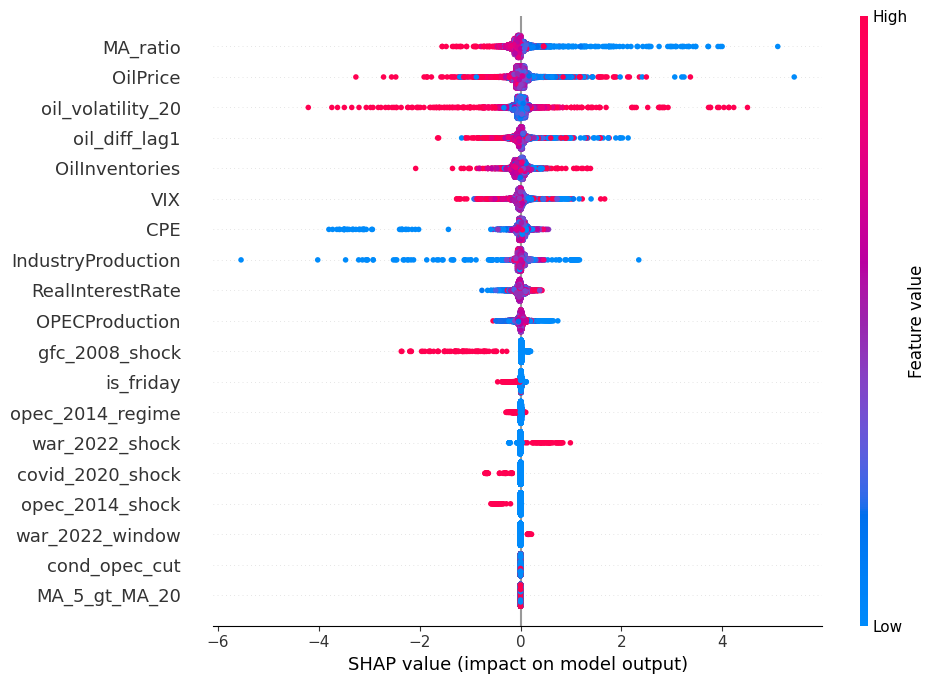

In [9]:
plt.rcParams.update({'font.size': 12})

# beeswarm
shap.summary_plot(shap_values, X, show=False, plot_size=(10, 7))
fig = plt.gcf()
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

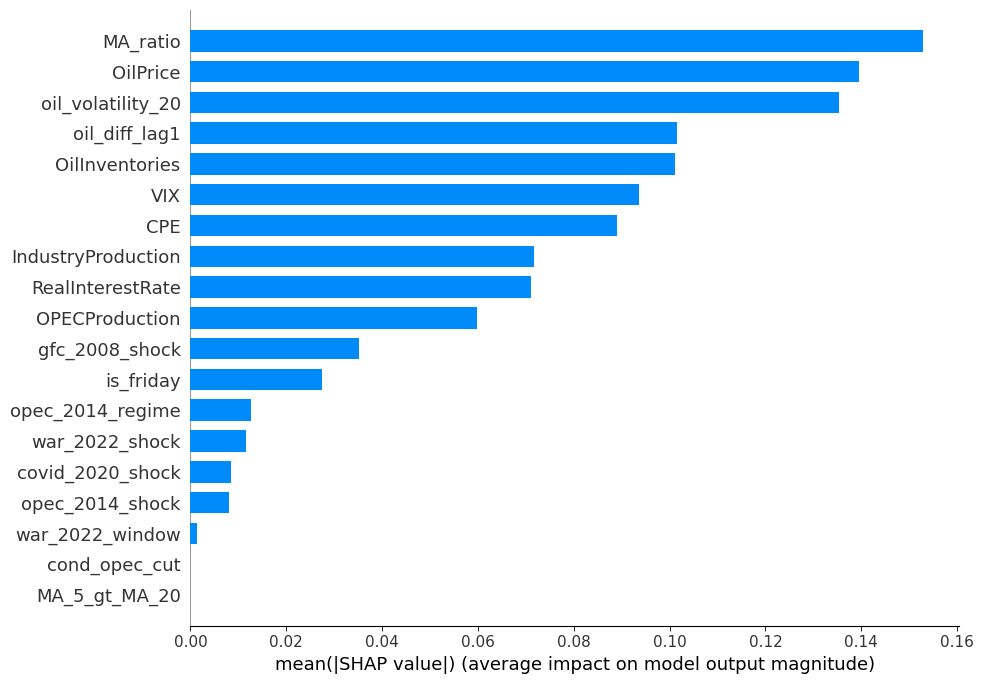

In [10]:
# bar
shap.summary_plot(shap_values, X, plot_type='bar', show=False, plot_size=(10, 7))
fig = plt.gcf()
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

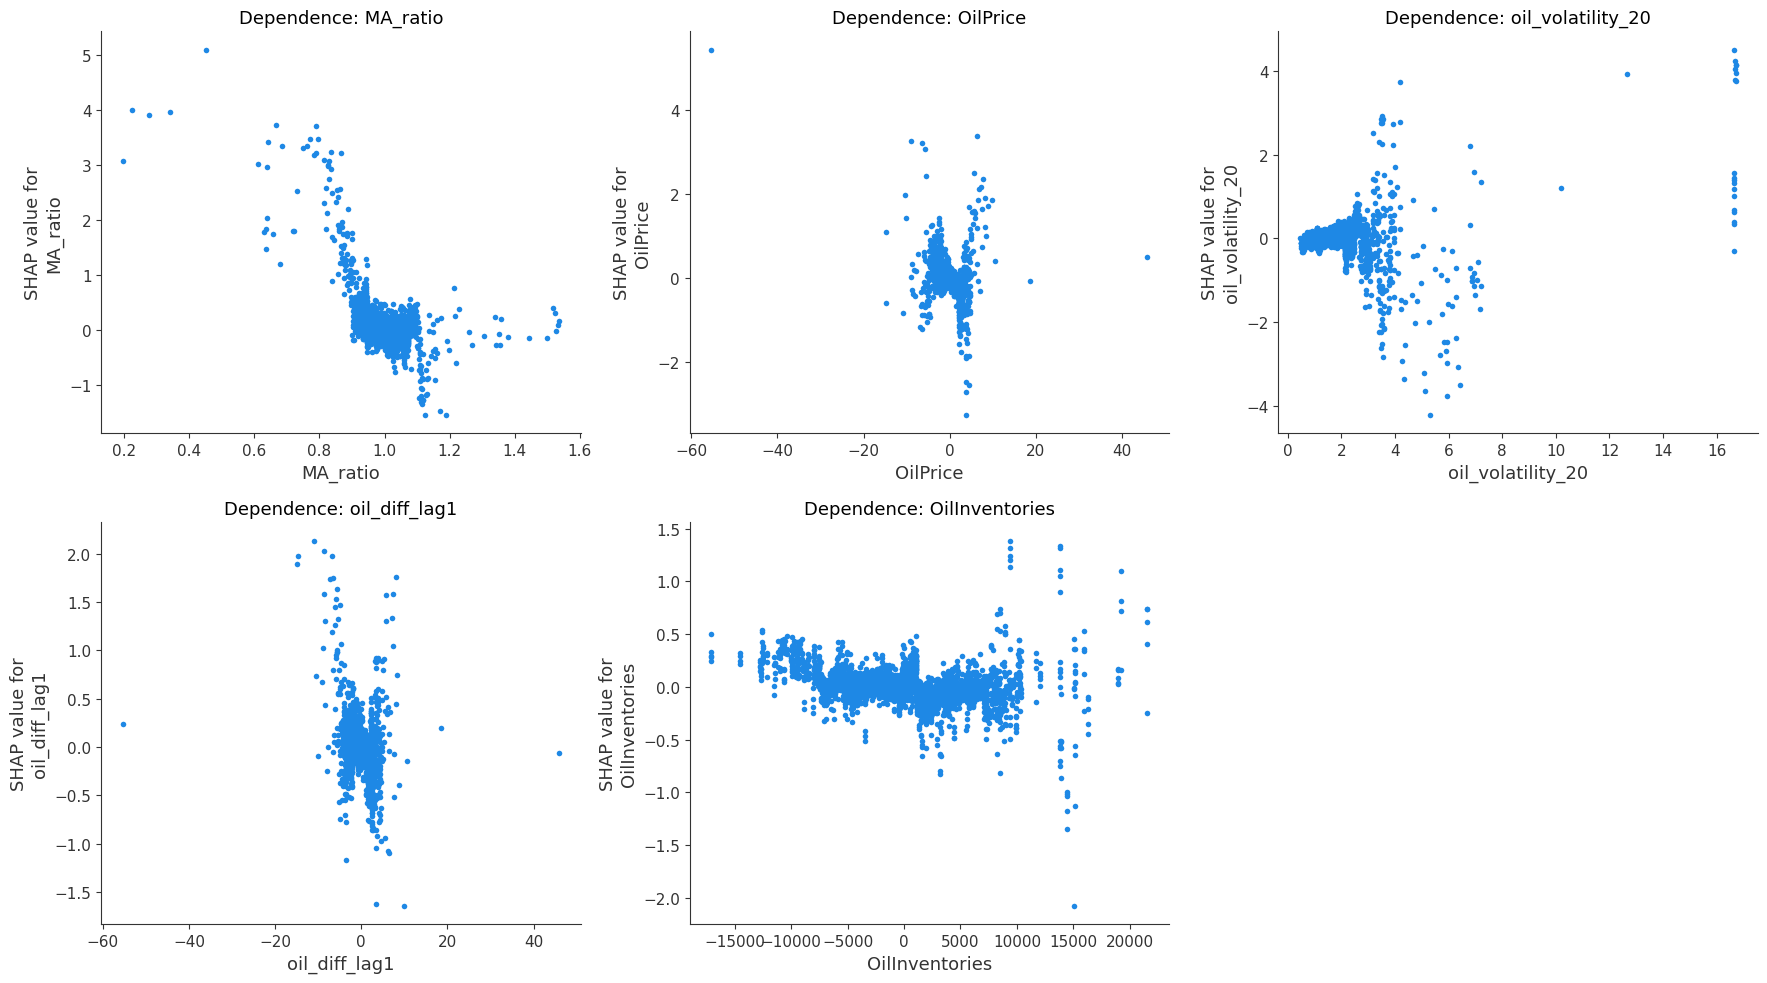

In [ ]:
# 상위 5개 dependence plot (해당 변수 값과 SHAP 값의 관계)
top5 = shap_summary['variable'].head(5).tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, var in enumerate(top5):
    shap.dependence_plot(var, shap_values, X, ax=axes[i], show=False, interaction_index=None)
    axes[i].set_title(f'Dependence: {var}', fontsize=13)
axes[-1].axis('off')
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'dependence_top5.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. OLS β ↔ SHAP 비교 표

In [12]:
ols = pd.read_csv(OLS_PATH)
ols.columns = [c.lstrip('\ufeff') for c in ols.columns]
ols = ols.rename(columns={'std_beta': 'std_beta_OLS'})
ols['sig_OLS'] = ols['p_HC3'] < 0.05
ols['sign_OLS'] = np.where(ols['std_beta_OLS'] >= 0, '+', '-')

shap_for_merge = shap_summary.rename(columns={'rank': 'rank_shap'}).copy()
shap_for_merge['sign_SHAP'] = np.where(shap_for_merge['mean_shap_signed'] >= 0, '+', '-')

cmp = ols[['variable', 'std_beta_OLS', 'p_HC3', 'sig_OLS', 'sign_OLS']].merge(
    shap_for_merge[['variable', 'mean_abs_shap', 'rank_shap', 'sign_SHAP']],
    on='variable', how='inner'
)
cmp['sign_match'] = cmp['sign_OLS'] == cmp['sign_SHAP']

# top_n: 변수 19개 → 상위 1/3 ≈ 6개를 '큼'으로 정의
n_feat = len(cmp)
top_n = max(4, n_feat // 3)
shap_top_set = set(cmp.sort_values('mean_abs_shap', ascending=False).head(top_n)['variable'])
beta_top_set = set(cmp.assign(abs_beta=cmp['std_beta_OLS'].abs())
                      .sort_values('abs_beta', ascending=False).head(top_n)['variable'])

def classify(row):
    v = row['variable']
    shap_big = v in shap_top_set
    beta_big = v in beta_top_set
    sig = row['sig_OLS']
    match = row['sign_match']
    if (not sig) and shap_big:
        return '순수 비선형 효과'
    if not match:
        return '상호작용 의심'
    if shap_big and beta_big:
        return '견고한 효과'
    if shap_big and not beta_big:
        return '비선형 추가 효과'
    if beta_big and not shap_big:
        return '선형 효과 위주'
    return '약한 효과'

cmp['case'] = cmp.apply(classify, axis=1)
cmp = cmp.sort_values('rank_shap').reset_index(drop=True)
cmp

,variable,std_beta_OLS,p_HC3,sig_OLS,sign_OLS,mean_abs_shap,rank_shap,sign_SHAP,sign_match,case
0,MA_ratio,-0.371292,0.047268,True,-,0.152826,1,+,False,상호작용 의심
1,OilPrice,-0.310233,0.260299,False,-,0.139621,2,-,True,순수 비선형 효과
2,oil_volatility_20,0.159637,0.204171,False,+,0.135443,3,-,False,순수 비선형 효과
3,oil_diff_lag1,-0.126802,0.053867,False,-,0.101643,4,+,False,순수 비선형 효과
4,OilInventories,-0.079703,0.007347,True,-,0.101028,5,-,True,비선형 추가 효과
5,VIX,-0.076236,0.070366,False,-,0.093688,6,+,False,순수 비선형 효과
6,CPE,0.272013,0.006196,True,+,0.088988,7,-,False,상호작용 의심
7,IndustryProduction,-0.132410,0.226879,False,-,0.071611,8,-,True,약한 효과
8,RealInterestRate,0.072186,0.032782,True,+,0.071107,9,-,False,상호작용 의심
9,OPECProduction,-0.081208,0.346946,False,-,0.059750,10,-,True,약한 효과


## 7. SHAP dependence 심화 분석
→ SHAP 중요도 상위 변수 중심

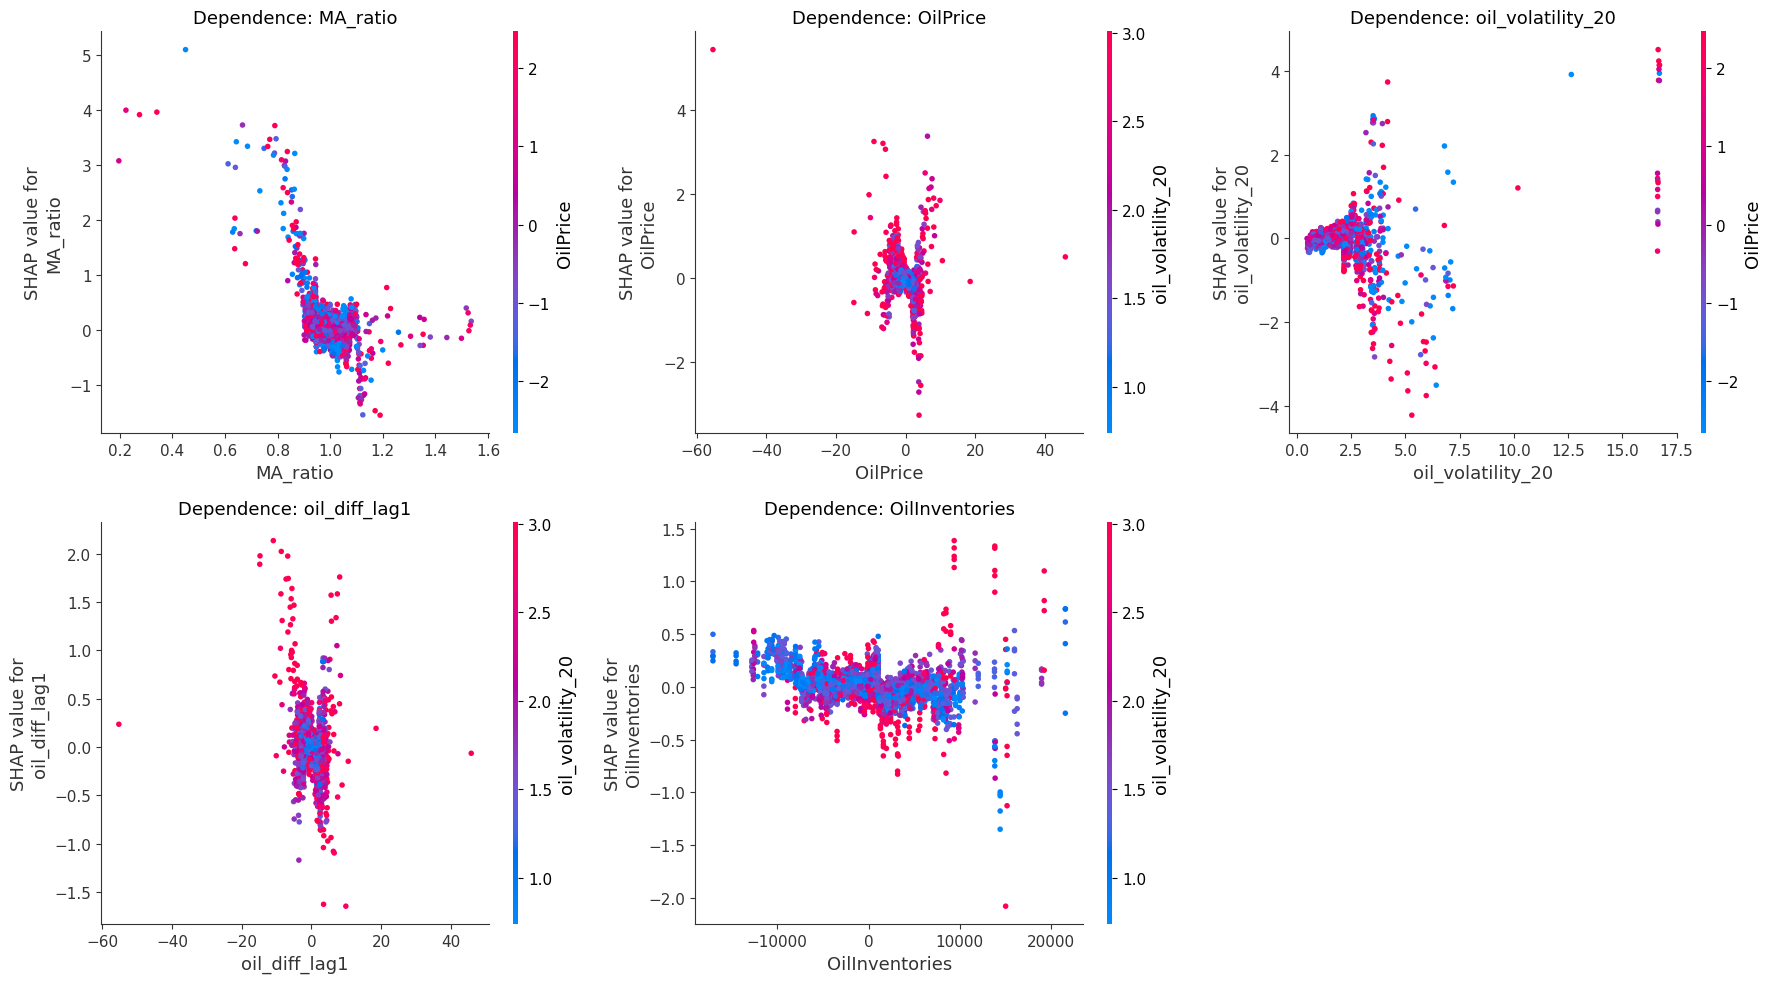

In [27]:
# 상위 5개 dependence plot 심화 분석 (상호작용 후보 확인)
top5 = shap_summary['variable'].head(5).tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, var in enumerate(top5):
    shap.dependence_plot(var, shap_values, X, ax=axes[i], show=False, interaction_index='auto')
    axes[i].set_title(f'Dependence: {var}', fontsize=13)
axes[-1].axis('off')
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'dependence_top5.png', dpi=150, bbox_inches='tight')
plt.show()

- 특정 변수의 SHAP 기여도가 다른 변수의 수준에 따라 어떻게 달라지는지를 시각화한다. 
- 'auto'는 모델 내부에서 dependence plot상 가장 강하게 상호작용하는 후보를 자동 선택한다. 
- 색상이 SHAP 값의 위아래 분포를 뚜렷하게 나눈다면, 해당 변수 간 상호작용 가능성이 있다고 해석할 수 있다.


| 변수 | auto가 선택한 상호작용 후보 | 해석 |
|---|---|---|
| `MA_ratio` | `OilPrice` | 이동평균 비율 효과가 유가 수준에 따라 달라질 가능성 |
| `OilPrice` | `oil_volatility_20` | 유가 수준 효과가 변동성 국면에 따라 달라질 가능성 |
| `oil_volatility_20` | `OilPrice` | 변동성 효과가 유가 수준과 결합되어 나타남 |
| `oil_diff_lag1` | `oil_volatility_20` | 전일 변화 효과가 변동성 국면에 따라 달라짐 |
| `OilInventories` | `oil_volatility_20` | 재고 효과의 강도가 변동성 수준에 따라 달라질 수 있음 |

## 8. 구간별 SHAP 부호 분포

OLS β ↔ SHAP 비교에서는 변수별 `mean_shap_signed`를 이용해 LGBM에서의 평균적인 방향성을 판단하였다. 
평본 절에서는 균적인 방향성에서 나아가 구간별 SHAP 방향이 어떻게 나타나는지 확인한다.

- 변수: SHAP 중요도가 높은 변수와 OLS β 부호와 SHAP 평균 부호가 불일치한 변수
- 방법: 변수 값을 분위수 구간으로 나누어 구간별 SHAP 방향을 확인
- 목적
1. 전체 평균 SHAP 부호가 변수의 효과 방향을 대표할 수 있는지 확인한다.
2. 변수 값의 구간에 따라 SHAP 부호가 바뀌는지 확인한다.
3. OLS β와 SHAP 평균 부호의 불일치가 구간별 비선형 효과에서 비롯된 것인지 검토한다.
4. 이후 spline 분석으로 보강할 필요가 있는 변수를 선별한다.

In [ ]:
# SHAP 상위 변수 + OLS/SHAP 부호 불일치 변수 추출
top_vars = shap_summary["variable"].head(8).tolist()
mismatch_vars = cmp.loc[~cmp["sign_match"], "variable"].tolist()

target_vars = []
for v in top_vars + mismatch_vars:
    if v in X.columns and v not in target_vars:
        target_vars.append(v)

# 더미/상수형 변수는 구간 분석에서 제외(분위수 구간 분석에 적합하지 X)
target_vars = [
    v for v in target_vars
    if X[v].nunique(dropna=True) > 5 and shap_summary.loc[shap_summary["variable"] == v, "mean_abs_shap"].iloc[0] > 0
]

print("구간별 SHAP 부호 분포 분석 대상:")
print(target_vars)

구간별 SHAP 부호 분포 분석 대상:
['MA_ratio', 'OilPrice', 'oil_volatility_20', 'oil_diff_lag1', 'OilInventories', 'VIX', 'CPE', 'IndustryProduction', 'RealInterestRate']


In [21]:
# 변수별 구간 분석
bin_rows = []

for var in target_vars:
    j = final_aic_features.index(var)

    tmp = pd.DataFrame({
        "variable": var,
        "x_value": X[var].values,
        "shap_value": shap_arr[:, j],
    })

    # 분위수 구간 생성
    # 하위 20%, 20~40%, 40~60%, 60~80%, 상위 20%
    tmp["bin"] = pd.qcut(
        tmp["x_value"],
        q=5,
        duplicates="drop"
    )

    # 최솟값, 최댓값, 평균값, 평균 SHAP, 평균 절대 SHAP, 양수 비율, 음수 비율 계산
    grouped = tmp.groupby("bin", observed=True).agg(
        x_min=("x_value", "min"),
        x_max=("x_value", "max"),
        mean_x=("x_value", "mean"),
        mean_shap=("shap_value", "mean"),
        mean_abs_shap=("shap_value", lambda s: np.abs(s).mean()),
        positive_ratio=("shap_value", lambda s: (s > 0).mean()),
        negative_ratio=("shap_value", lambda s: (s < 0).mean()),
    ).reset_index()

    grouped["variable"] = var
    grouped["bin_order"] = np.arange(1, len(grouped) + 1)

    # 구간별 평균 SHAP 부호
    grouped["sign_by_bin"] = np.where(
        grouped["mean_shap"] > 0, "+",
        np.where(grouped["mean_shap"] < 0, "-", "0")
    )

    # 전체 평균 SHAP 부호
    overall_mean = tmp["shap_value"].mean()
    grouped["overall_sign"] = "+" if overall_mean > 0 else ("-" if overall_mean < 0 else "0")

    bin_rows.append(grouped)

shap_bin_summary = pd.concat(bin_rows, ignore_index=True)

display_cols = [
    "variable",
    "bin_order",
    "x_min",
    "x_max",
    "mean_shap",
    "positive_ratio",
    "sign_by_bin",
    "overall_sign",
]

display(shap_bin_summary[display_cols].round(4))

,variable,bin_order,x_min,x_max,mean_shap,positive_ratio,sign_by_bin,overall_sign
0,MA_ratio,1,0.1963,0.9680,0.3417,0.8615,+,+
1,MA_ratio,2,0.9680,0.9950,-0.0030,0.4672,-,+
2,MA_ratio,3,0.9950,1.0138,-0.0642,0.0990,-,+
3,MA_ratio,4,1.0138,1.0340,-0.0762,0.1220,-,+
4,MA_ratio,5,1.0341,1.5360,-0.0919,0.2417,-,+
5,OilPrice,1,-55.2900,-1.1000,0.1648,0.8054,+,-
6,OilPrice,2,-1.1000,-0.2500,0.0334,0.6969,+,-
7,OilPrice,3,-0.2400,0.3700,0.0079,0.5305,+,-
8,OilPrice,4,0.3700,1.1300,-0.0398,0.2607,-,-
9,OilPrice,5,1.1300,45.8900,-0.1704,0.1094,-,-


C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\3394636994.py:24: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\3394636994.py:24: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\3394636994.py:24: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\3394636994.py:24: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\3394636994.py:24: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\3394636994.py:24: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font

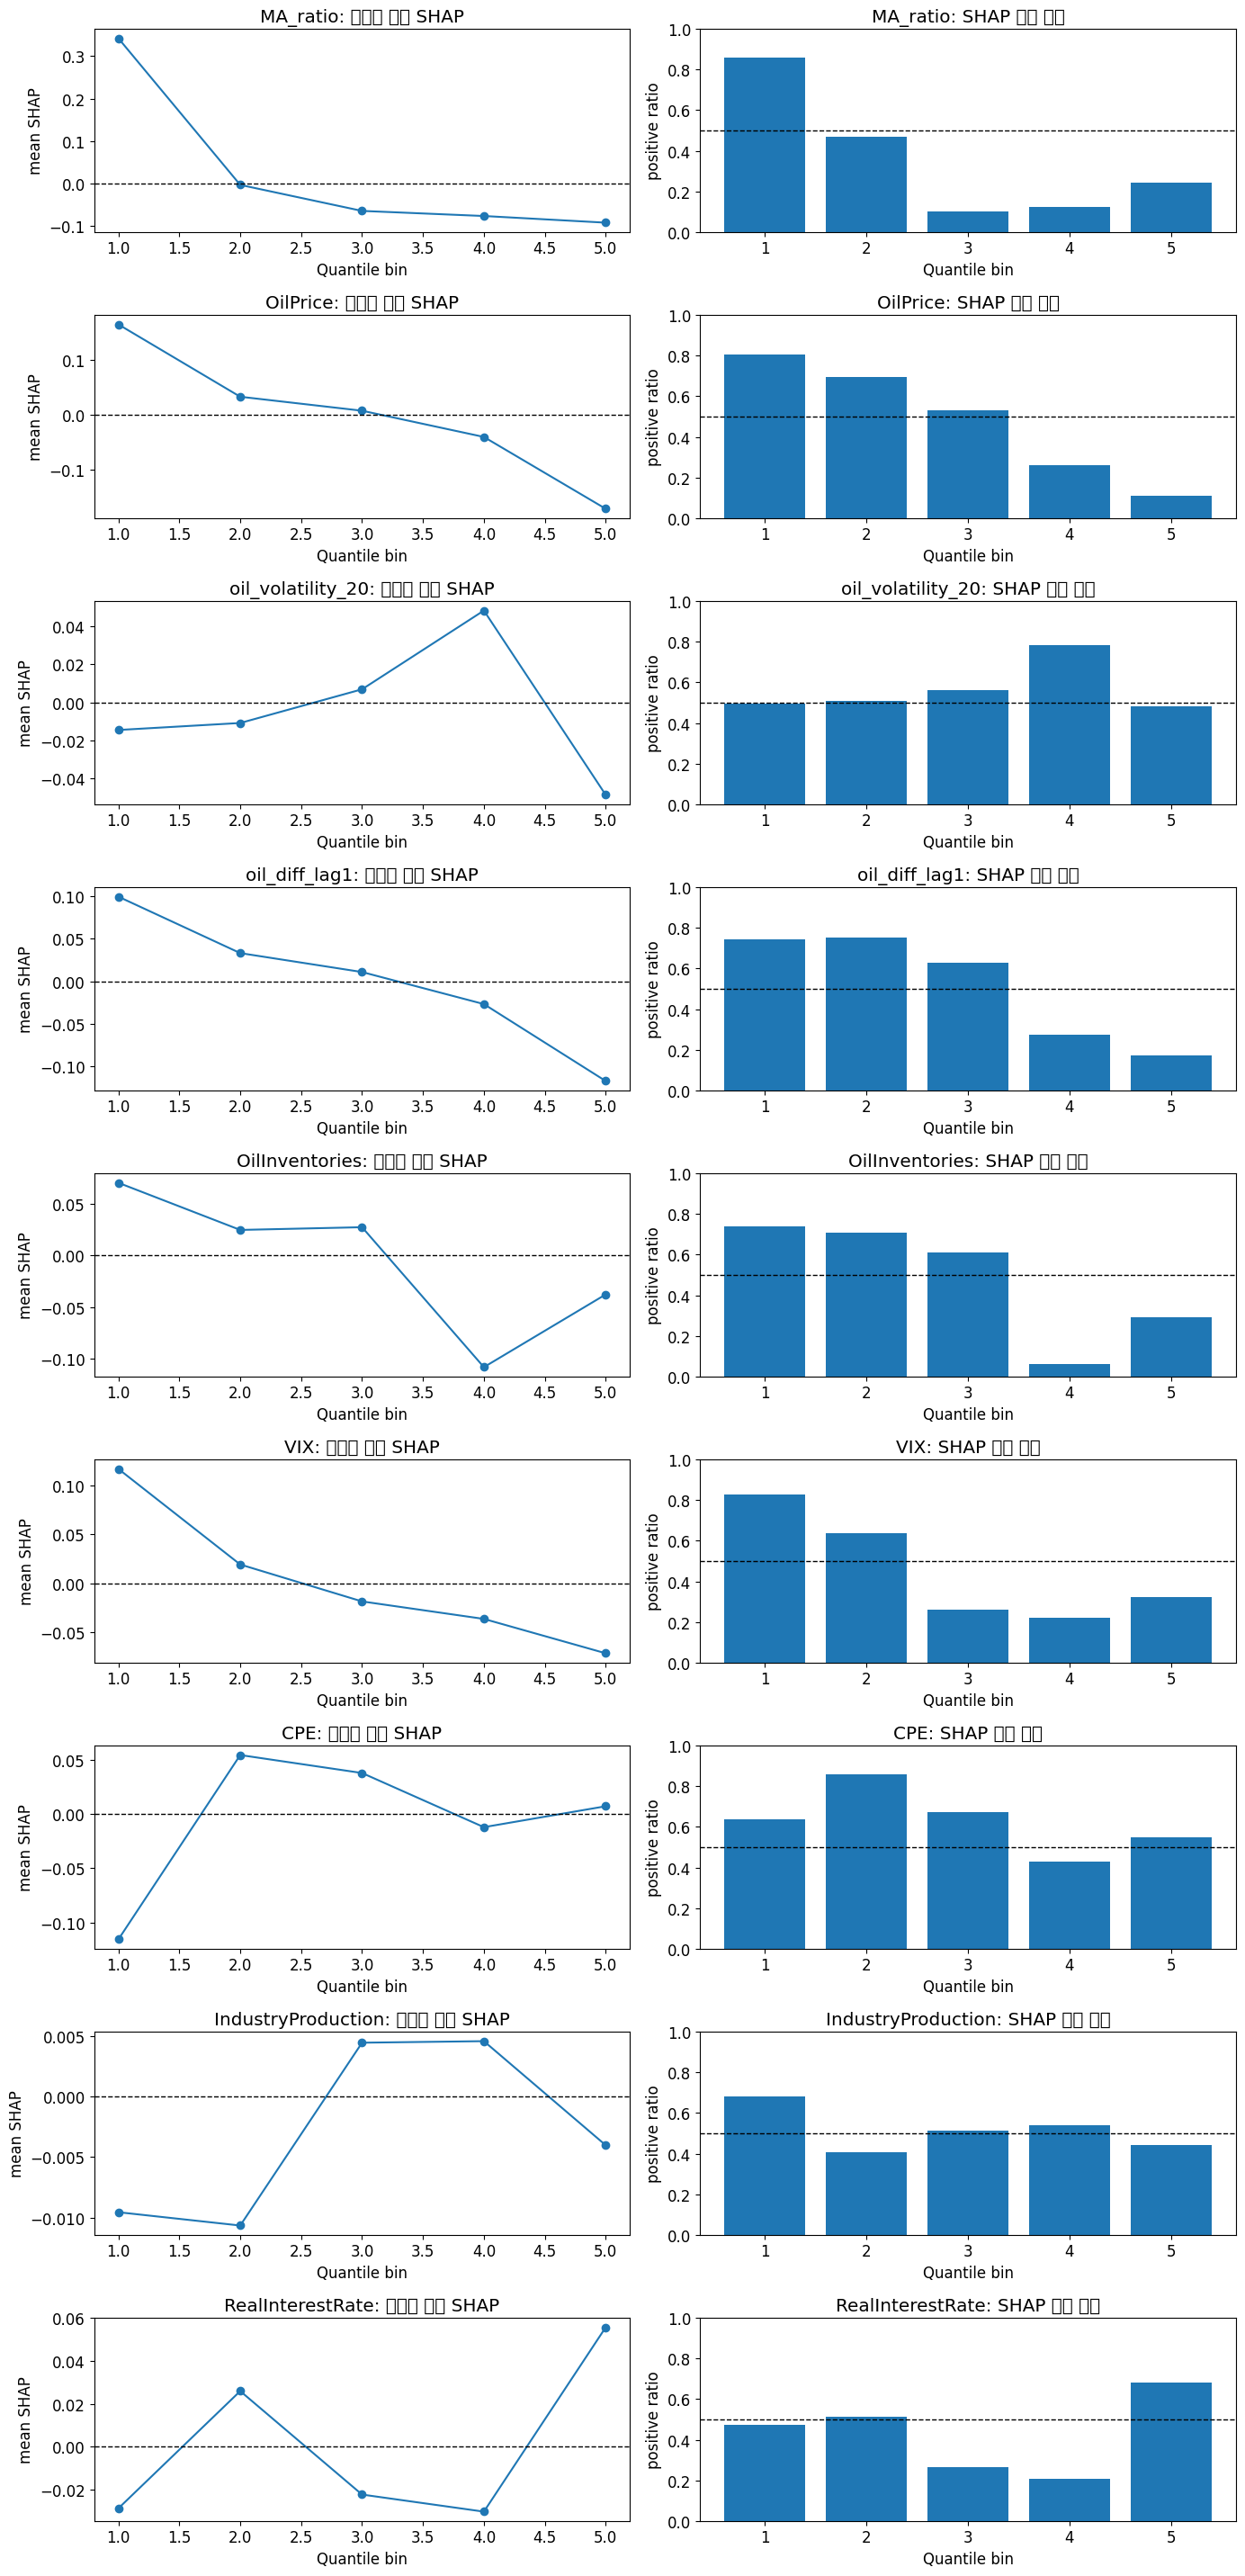

In [22]:
# 변수별로 구간별 평균 SHAP / 양수 비율 시각화
n_vars = len(target_vars)
fig, axes = plt.subplots(n_vars, 2, figsize=(14, 3.2 * n_vars))

if n_vars == 1:
    axes = np.array([axes])

for r, var in enumerate(target_vars):
    sub = shap_bin_summary[shap_bin_summary["variable"] == var].copy()

    axes[r, 0].plot(sub["bin_order"], sub["mean_shap"], marker="o")
    axes[r, 0].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[r, 0].set_title(f"{var}: 구간별 평균 SHAP")
    axes[r, 0].set_xlabel("Quantile bin")
    axes[r, 0].set_ylabel("mean SHAP")

    axes[r, 1].bar(sub["bin_order"], sub["positive_ratio"])
    axes[r, 1].axhline(0.5, color="black", linewidth=1, linestyle="--")
    axes[r, 1].set_ylim(0, 1)
    axes[r, 1].set_title(f"{var}: SHAP 양수 비율")
    axes[r, 1].set_xlabel("Quantile bin")
    axes[r, 1].set_ylabel("positive ratio")

fig.tight_layout()
fig.savefig(BASELINE_DIR / "shap_bin_sign_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

[해석]
- `MA_ratio`, `OilPrice`, `oil_volatility_20`, `oil_diff_lag1`, `OilInventories`는 구간별 SHAP 부호 전환이 뚜렷하여 비선형 효과가 의심된다. 따라서 평균 SHAP 부호 하나로 해석하기보다, spline 분석을 통해 구간별 비선형 효과를 추가로 확인할 필요가 있다.
- `CPE`와 `RealInterestRate`는 부호 변화가 불규칙해 단독 비선형보다는 상호작용 가능성이 크며 dependence plot을 확인할 필요가 있다. 

| 구분 | 변수 | 구간별 SHAP 패턴 | 해석 |
|---|---|---|---|
| 비선형 의심 | `MA_ratio` | 1구간 `+`, 2~5구간 `-` | 낮은 구간에서만 강한 양의 효과가 나타나 평균 부호만으로 해석하기 어려움 |
| 비선형 의심 | `OilPrice` | 낮은 구간 `+`, 높은 구간 `-` | 가격 변화 수준에 따라 예측 기여 방향이 전환됨 |
| 비선형 의심 | `oil_volatility_20` | 중간 구간 `+`, 최고 구간 `-` | 변동성 수준에 따라 효과 방향이 달라지는 threshold형 패턴 |
| 비선형 의심 | `oil_diff_lag1` | 낮은 구간 `+`, 높은 구간 `-` | 전일 변화가 큰 양수일 때 반전 효과 가능 |
| 비선형 의심 | `OilInventories` | 낮은 재고 `+`, 높은 재고 `-` | 재고 수준에 따라 효과 방향이 달라지며, 경제적으로 해석 가능 |
| 비선형 의심 | `VIX` | 낮은 구간 `+`, 중간 이상 `-` | VIX 변화 수준에 따라 효과 방향이 전환됨 |
| 상호작용 의심 | `CPE` | `-`, `+`, `+`, `-`, `+` | 구간별 방향이 불규칙해 단독 비선형보다 다른 변수와의 상호작용 가능성 |
| 상호작용 의심 | `RealInterestRate` | `-`, `+`, `-`, `-`, `+` | 구간별 부호가 안정적이지 않아 상호작용 가능성 |
| 약하거나 애매 | `IndustryProduction` | 부호 혼재, 평균 SHAP 작음 | 구간별 패턴이 뚜렷하지 않고 영향력이 상대적으로 약함 |


In [23]:
# 저장
shap_bin_summary.to_csv(BASELINE_DIR / "shap_bin_sign_distribution.csv", index=False)
print("저장 완료:")
print(" -", BASELINE_DIR / "shap_bin_sign_distribution.csv")
print(" -", BASELINE_DIR / "shap_bin_sign_distribution.png")

저장 완료:
 - ..\outputs\baseline\shap_bin_sign_distribution.csv
 - ..\outputs\baseline\shap_bin_sign_distribution.png


## 9. 비선형 효과 보강 분석

### 9-1. PDP를 통한 LGBM 비선형 패턴 확인

### 9-2. Spline OLS를 통한 비선형 효과 재검토

LGBM-SHAP에서 비선형 효과가 의심된 주요 변수들을 대상으로 spline 회귀를 적용한다.

기존 OLS는 변수 효과를 하나의 직선 관계로 가정하지만, spline은 변수 값의 구간에 따라 효과가 달라지는지를 확인할 수 있다. 이를 통해 OLS beta와 SHAP 해석이 불일치한 이유가 비선형·구간별 효과 때문인지 점검한다.

- 기준 모델: 기존 AIC OLS
- 보강 모델: 주요 변수에 spline 항을 추가한 OLS
- 비교 기준: AIC, test RMSE, R², 변수별 spline curve

## 10. 상호작용 의심변수 재확인
→ 구간별 부호가 불규칙했던 CPE, RealInterestRate 집중 확인

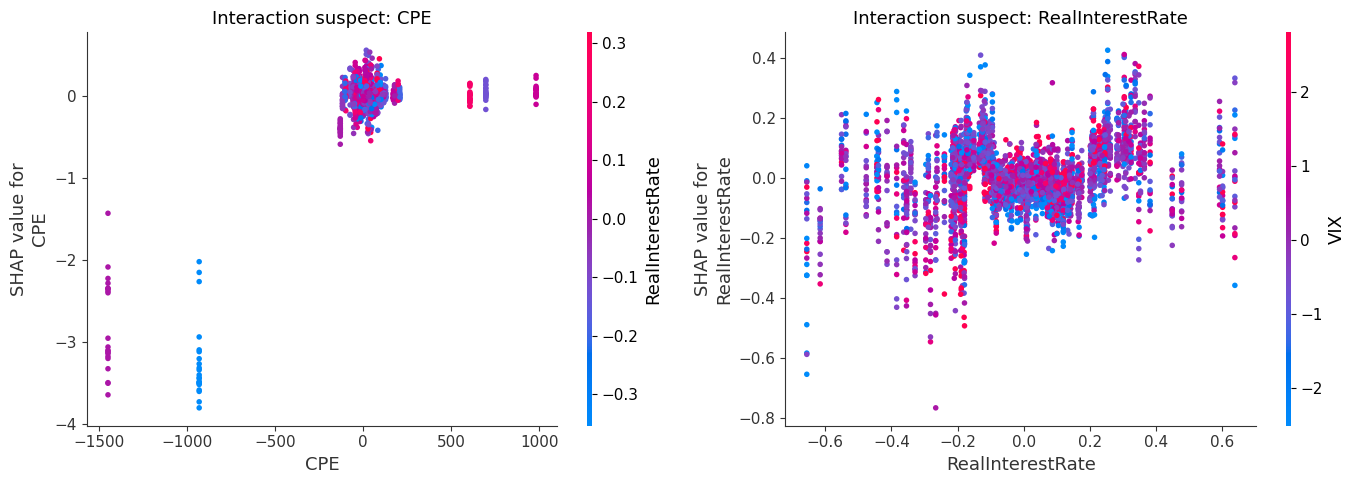

In [28]:
# 상호작용 의심 변수 확인
interaction_suspect_vars = ["CPE", "RealInterestRate"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()
for i, var in enumerate(interaction_suspect_vars):
    shap.dependence_plot(var, shap_values, X, ax=axes[i], show=False, interaction_index='auto')
    axes[i].set_title(f'Interaction suspect: {var}', fontsize=13)

fig.tight_layout()
fig.savefig(BASELINE_DIR / 'dependence_interaction_suspects.png', dpi=150, bbox_inches='tight')
plt.show()

[해석]

- `CPE`의 상호작용 후보: `RealInterestRate`
- `RealInterestRate`의 상호작용 후보: `VIX`

구간별 SHAP 부호 분석에서 CPE와 RealInterestRate는 방향이 불규칙하게 나타났고, dependence plot에서도 단순한 비선형 곡선보다는 다른 변수 수준에 따라 효과가 달라지는 패턴을 보이고 있다. 그러므로 두 변수는 단독 효과보다는 상호작용 관점에서 해석하는 것이 더 적절하다.

## 11. 양면 bar chart (paired importance)

C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\937111570.py:21: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\937111570.py:21: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\937111570.py:21: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\937111570.py:21: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\937111570.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\이은서\AppData\Local\Temp\ipykernel_18640\937111570.py:21: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu S

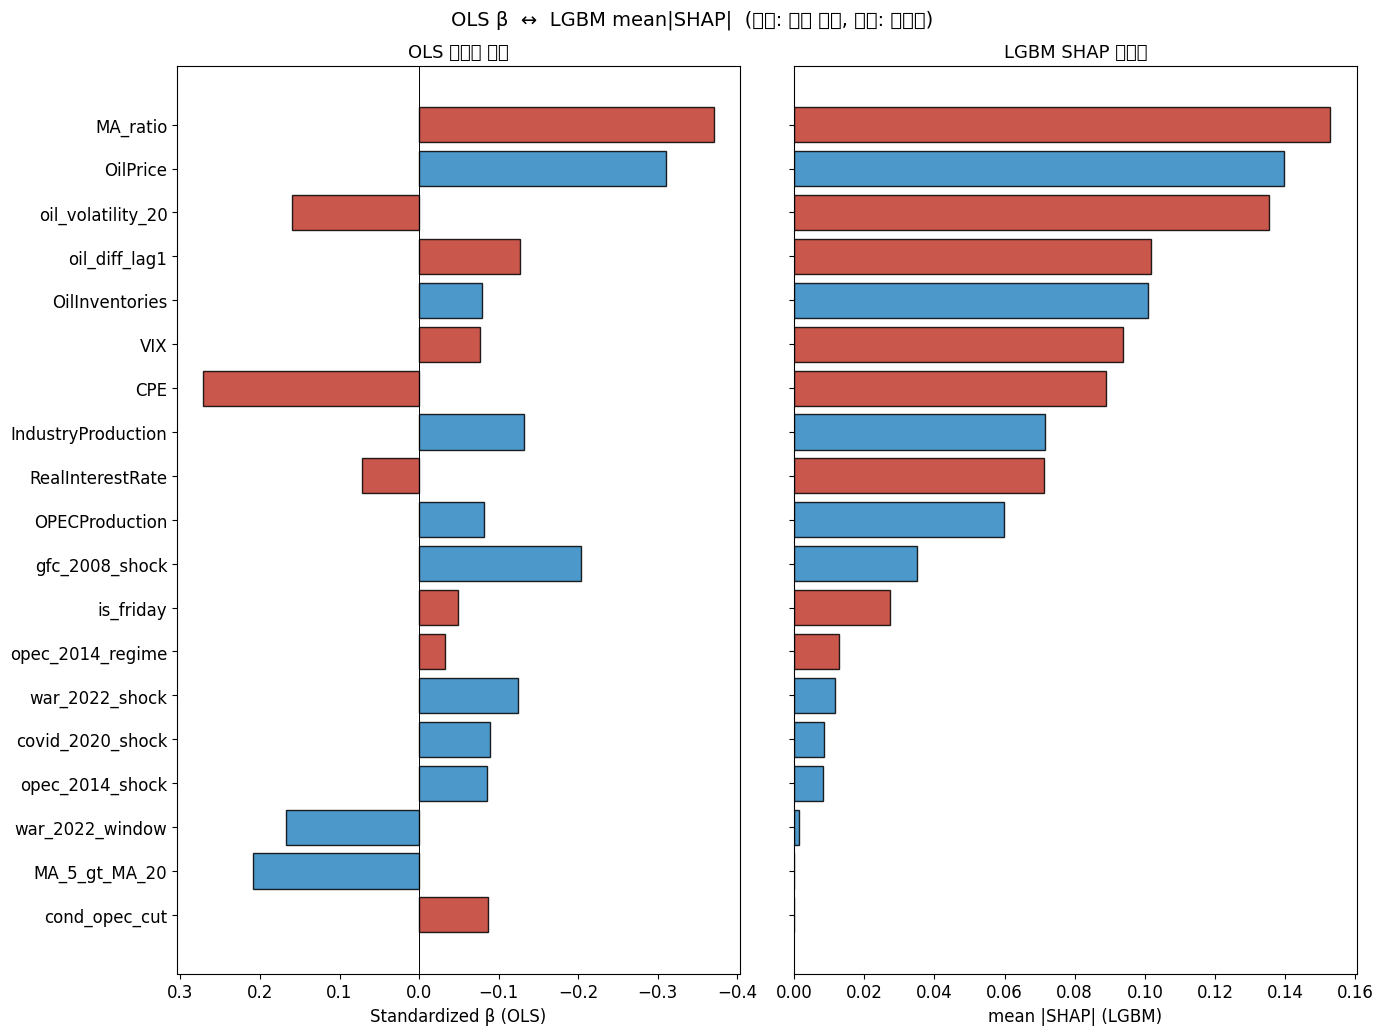

In [13]:
order = cmp.sort_values('mean_abs_shap', ascending=True).reset_index(drop=True)
yloc = np.arange(len(order))

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 0.45 * len(order) + 2), sharey=True)

colors = ['#2E86C1' if m else '#C0392B' for m in order['sign_match']]

ax_l.barh(yloc, order['std_beta_OLS'], color=colors, edgecolor='black', alpha=0.85)
ax_l.axvline(0, color='black', lw=0.7)
ax_l.invert_xaxis()
ax_l.set_yticks(yloc)
ax_l.set_yticklabels(order['variable'])
ax_l.set_xlabel('Standardized β (OLS)', fontsize=12)
ax_l.set_title('OLS 표준화 계수', fontsize=13)

ax_r.barh(yloc, order['mean_abs_shap'], color=colors, edgecolor='black', alpha=0.85)
ax_r.set_xlabel('mean |SHAP| (LGBM)', fontsize=12)
ax_r.set_title('LGBM SHAP 중요도', fontsize=13)

fig.suptitle('OLS β  ↔  LGBM mean|SHAP|  (파랑: 부호 일치, 빨강: 불일치)', fontsize=14)
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'paired_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. 케이스별 해석 문장 자동 생성

In [14]:
for _, row in cmp.iterrows():
    beta = row['std_beta_OLS']
    p = row['p_HC3']
    mshap = row['mean_abs_shap']
    p_txt = f'p<0.01' if p < 0.01 else (f'p<0.05' if p < 0.05 else f'p={p:.3f}')
    sign_txt = '부호 일치' if row['sign_match'] else '부호 불일치'
    print(f"{row['variable']:25s} | OLS β = {beta:+.4f} ({p_txt}), mean|SHAP| = {mshap:.4f} | {sign_txt} → {row['case']}")

MA_ratio                  | OLS β = -0.3713 (p<0.05), mean|SHAP| = 0.1528 | 부호 불일치 → 상호작용 의심
OilPrice                  | OLS β = -0.3102 (p=0.260), mean|SHAP| = 0.1396 | 부호 일치 → 순수 비선형 효과
oil_volatility_20         | OLS β = +0.1596 (p=0.204), mean|SHAP| = 0.1354 | 부호 불일치 → 순수 비선형 효과
oil_diff_lag1             | OLS β = -0.1268 (p=0.054), mean|SHAP| = 0.1016 | 부호 불일치 → 순수 비선형 효과
OilInventories            | OLS β = -0.0797 (p<0.01), mean|SHAP| = 0.1010 | 부호 일치 → 비선형 추가 효과
VIX                       | OLS β = -0.0762 (p=0.070), mean|SHAP| = 0.0937 | 부호 불일치 → 순수 비선형 효과
CPE                       | OLS β = +0.2720 (p<0.01), mean|SHAP| = 0.0890 | 부호 불일치 → 상호작용 의심
IndustryProduction        | OLS β = -0.1324 (p=0.227), mean|SHAP| = 0.0716 | 부호 일치 → 약한 효과
RealInterestRate          | OLS β = +0.0722 (p<0.05), mean|SHAP| = 0.0711 | 부호 불일치 → 상호작용 의심
OPECProduction            | OLS β = -0.0812 (p=0.347), mean|SHAP| = 0.0597 | 부호 일치 → 약한 효과
gfc_2008_shock            | OLS β = -0.2034 (p<0.05), mean|SHA

## 13. 저장

In [15]:
shap_summary.to_csv(BASELINE_DIR / 'lgbm_shap_summary.csv', index=False)
cmp.to_csv(BASELINE_DIR / 'interpretation_compare.csv', index=False)
np.save(BASELINE_DIR / 'shap_values.npy', shap_arr)

print('저장 완료:')
for f in ['lgbm_shap_summary.csv', 'interpretation_compare.csv', 'shap_values.npy',
          'shap_summary.png', 'shap_summary_bar.png', 'dependence_top5.png', 'paired_importance.png']:
    print(' -', BASELINE_DIR / f)

저장 완료:
 - ..\outputs\baseline\lgbm_shap_summary.csv
 - ..\outputs\baseline\interpretation_compare.csv
 - ..\outputs\baseline\shap_values.npy
 - ..\outputs\baseline\shap_summary.png
 - ..\outputs\baseline\shap_summary_bar.png
 - ..\outputs\baseline\dependence_top5.png
 - ..\outputs\baseline\paired_importance.png
